Loaded JSON Lines format

Dataset Loaded Successfully

Columns:
Index(['content', 'annotation', 'extras'], dtype='object')

Dataset Shape: (220, 7)

Training Shape: (176, 9959)
Testing Shape: (44, 9959)

Model Training Completed

First 10 Predictions:
[977.68 204.3  956.01 350.79 387.17 448.98  98.56 156.13 690.6  581.15]

MSE: 0.0001
RMSE: 0.0074
R2 Score: 1.0
Tolerance Accuracy: 100.0 %

Predicted Candidate Score:
71.13


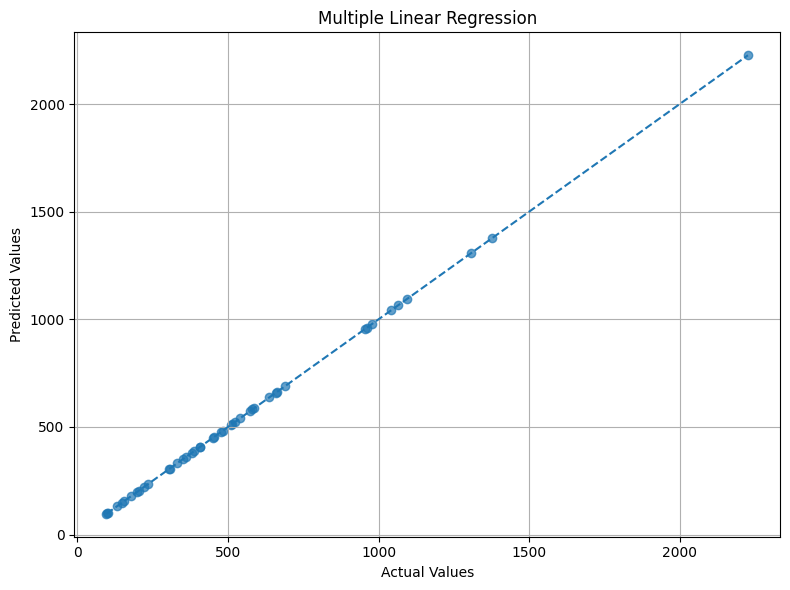

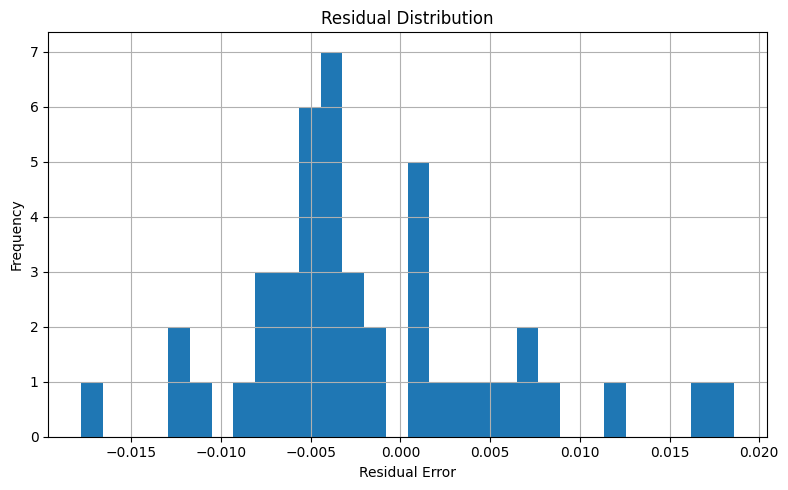


Top Features:
                    Feature  Coefficient
9958       annotation_count     7.999043
9957             word_count     0.500021
9956          resume_length     0.029998
278                  amazon     0.016017
5860                 oracle     0.007668
3652                  gupta     0.005805
6190               physical     0.005534
428   application developer     0.005424
9600               weblogic     0.005327
8450               supplier     0.005307
8508                    svn     0.005198
3268               features     0.005145
5878          oracle fusion     0.005000
9464               velocity     0.004838
2398          developer sap     0.004791
9356                  using     0.004709
3476                 fusion     0.004511
1061                 builds     0.004185
8033                    soa     0.004136
6450                  prime     0.004119

Model Saved Successfully


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score
)

json_file = "resume_dataset.json"

try:
    data = pd.read_json(json_file, lines=True)
    print("Loaded JSON Lines format")
except:
    data = pd.read_json(json_file)
    print("Loaded Standard JSON format")

print("\nDataset Loaded Successfully")

print("\nColumns:")
print(data.columns)

text_col = "content"

data["resume_length"] = data[text_col].astype(str).apply(len)

data["word_count"] = data[text_col].astype(str).apply(
    lambda x: len(x.split())
)

data["annotation_count"] = data["annotation"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

data["Generated_Score"] = (
    data["resume_length"] * 0.03
    + data["word_count"] * 0.5
    + data["annotation_count"] * 8
)

target_col = "Generated_Score"

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

data[text_col] = data[text_col].apply(clean_text)

data = data.dropna(subset=[text_col])

data = data[data[text_col].str.strip() != ""]

print("\nDataset Shape:", data.shape)

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

text_features = vectorizer.fit_transform(data[text_col])

text_df = pd.DataFrame(
    text_features.toarray(),
    columns=vectorizer.get_feature_names_out()
)

extra_features = data[
    [
        "resume_length",
        "word_count",
        "annotation_count"
    ]
].reset_index(drop=True)

X = pd.concat(
    [text_df, extra_features],
    axis=1
)

y = data[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

print("\nModel Training Completed")

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(np.round(y_pred[:10], 2))

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMSE:", round(mse, 4))

print("RMSE:", round(rmse, 4))

print("R2 Score:", round(r2, 4))

tolerance = 10

correct = np.sum(
    np.abs(y_test - y_pred) <= tolerance
)

accuracy = correct / len(y_test)

print("Tolerance Accuracy:", round(accuracy * 100, 2), "%")

new_resume = """
Python Machine Learning Deep Learning
SQL NLP TensorFlow Data Science
"""

new_resume_clean = clean_text(new_resume)

new_text = vectorizer.transform(
    [new_resume_clean]
)

new_text_df = pd.DataFrame(
    new_text.toarray(),
    columns=vectorizer.get_feature_names_out()
)

new_extra = pd.DataFrame({
    "resume_length": [len(new_resume)],
    "word_count": [len(new_resume.split())],
    "annotation_count": [8]
})

new_input = pd.concat(
    [new_text_df, new_extra],
    axis=1
)

prediction = model.predict(new_input)

print("\nPredicted Candidate Score:")
print(round(float(prediction[0]), 2))

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())

max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Multiple Linear Regression")

plt.grid(True)

plt.tight_layout()

plt.savefig("multiple_linear_regression.png")

plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(True)

plt.tight_layout()

plt.savefig("residual_distribution.png")

plt.show()

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop Features:")

print(feature_importance.head(20))

joblib.dump(
    model,
    "multiple_linear_regression_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print("\nModel Saved Successfully")